# Example Workflow

A demonstration of how to use the functions from `cmip6_utils.py` to retrieve the CMIP6 data and store it in JSON readable formats

In [1]:
import cmip6_utils as utils

Say we're interested in investigating simulations involving sea levels changes. The variable `zostoga` is for datasets that Global Average Thermosteric Sea Level Change, meaning sea level changes that result from the expansion of water due to global warming. We're interested in exploring what this looks like in the future under large fossil fuel use, which is covered by the SSP5-8.5 scenario, or `ssp585` under `experiment_id`. Say we're interested specifically in models conducted by NASA's Goddard Institute of Space Studies.

In [2]:
utils.filter_zstore_df(institution_id='NASA', variable_id='zostoga', experiment_id='ssp585')

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
404626,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r1i1p5f1,Omon,zostoga,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115
404704,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r1i1p3f1,Omon,zostoga,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115
404853,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r2i1p3f1,Omon,zostoga,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115
405133,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r3i1p3f1,Omon,zostoga,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115
406272,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r5i1p3f1,Omon,zostoga,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115
406327,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r4i1p3f1,Omon,zostoga,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115


We'll look at the data from their simulation at index `404626`

In [4]:
nasa_zostoga = utils.retrieve_xarr(utils.zstores.loc[404626].zstore)
nasa_zostoga

<xarray.Dataset> Size: 29kB
Dimensions:    (time: 1032, bnds: 2)
Coordinates:
  * time       (time) object 8kB 2015-01-16 12:00:00 ... 2100-12-16 12:00:00
    time_bnds  (time, bnds) object 17kB dask.array<chunksize=(1032, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    zostoga    (time) float32 4kB dask.array<chunksize=(516,), meta=np.ndarray>
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    cmor_version:           3.3.2
    ...                     ...
    table_id:               Omon
    table_info:             Creation Date:(21 March 2018) MD5:d211846f9d8f448...
    title:                  GISS-E2-1-G output prepared for CMIP6
    tracking_id:            hdl:21.14100/4b676854-2db9-4aa0-a82e-bbcce1c06ff8
    variable_id:            zostoga
    variant_label:          r1i1p5f1

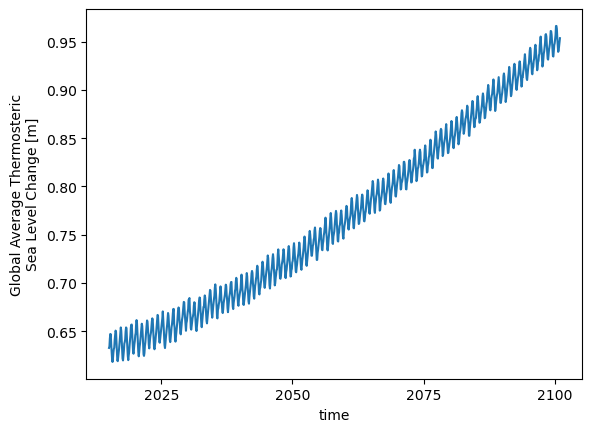

In [5]:
import matplotlib.pyplot as plt
nasa_zostoga.zostoga.squeeze().plot()

Say We're also interested in the sea surface height (from the geoid) geospatially across the globe.

In [6]:
utils.filter_zstore_df(variable_id='zos', institution_id='NASA', experiment_id='ssp585')

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
404625,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r1i1p5f1,Omon,zos,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115
404758,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r1i1p3f1,Omon,zos,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115
404836,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r2i1p3f1,Omon,zos,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115
405167,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r3i1p3f1,Omon,zos,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115
406270,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r5i1p3f1,Omon,zos,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115
406338,ScenarioMIP,NASA-GISS,GISS-E2-1-G,ssp585,r4i1p3f1,Omon,zos,gn,gs://cmip6/CMIP6/ScenarioMIP/NASA-GISS/GISS-E2...,NaN,20200115


In [7]:
nasa_zos = utils.retrieve_xarr(utils.zstores.loc[406338].zstore)
nasa_zos

<xarray.Dataset> Size: 214MB
Dimensions:    (time: 1032, lat: 180, lon: 288, bnds: 2)
Coordinates:
  * time       (time) object 8kB 2015-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat        (lat) float64 1kB -90.0 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 90.0
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    lat_bnds   (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    time_bnds  (time, bnds) object 17kB dask.array<chunksize=(1032, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    zos        (time, lat, lon) float32 214MB dask.array<chunksize=(241, 180, 288), meta=np.ndarray>
Attributes: (12/49)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    cmor_version:           3.3.2
    ...                     ...
    table_id:               Omon
    table_info:             Creation Date:(21 March 2018) MD5:c205bf4c8f9a982...
    title:                  GISS-E2-1-G output prepared for CMIP6
    tracking_id:            hdl:21.14100/1d4157da-3ad8-4ba6-aaf9-9f7b1704d55b...
    variable_id:            zos
    variant_label:          r4i1p3f1

Lets compare the projected ocean levels in 2025 to 2100

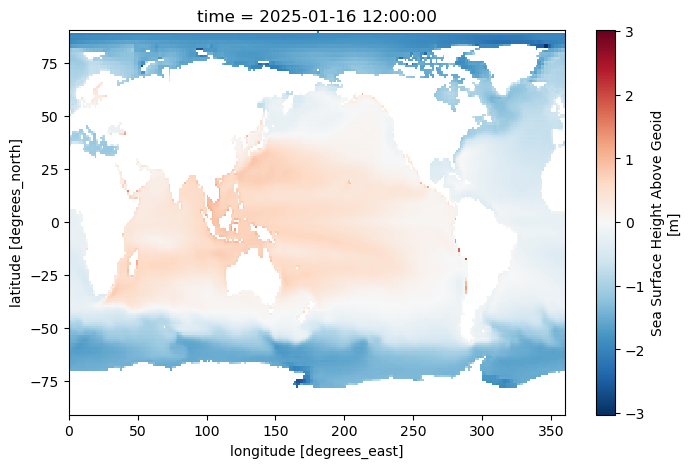

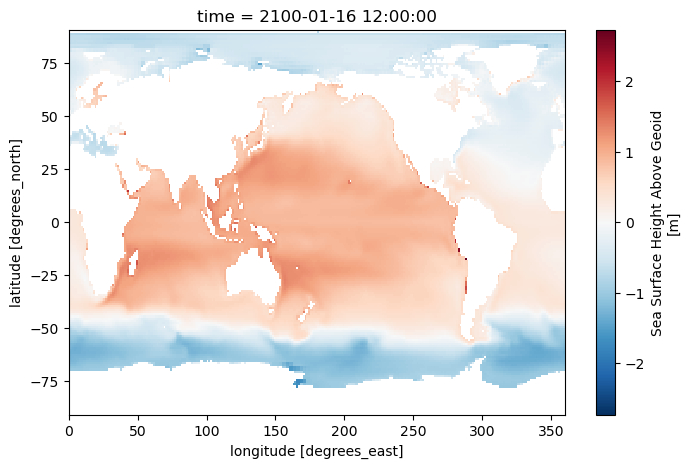

In [8]:
nasa_zos.sel(time="2025-01").zos.squeeze().plot(figsize=(8, 5))
nasa_zos.sel(time="2100-01").zos.squeeze().plot(figsize=(8, 5))

Now we want to take these two xarrays and turn them into json files so we can graph them in D3 on our web platform. First lets look at what one of these arrays looks like as a python dictionary. The height above geoid dataset contains monthly data over the course of 85 simulated years, resulting in time length of 1032 points, across a 180x288 size grid.

In [9]:
nasa_zos_dict = utils.to_json_str( nasa_zos, as_str=False )

Now, we'll call to_json_file from cmip6_utils to turn them into json files.

In [10]:
utils.to_json_file( nasa_zostoga, filename='ssp585_zostoga' )
utils.to_json_file( nasa_zos_dict, filename='ssp585_zos' )

Be aware that there is lots of data stored in some of these xarrays. Our zostoga file, which mentioned earlier has 1032x180x288 points of data, is nearly 2 Gigabytes. It may be wise to perform preprocessing, such as taking the mean across years, or sampling from a specific date, in order to reduce the amount of data.

The module and functions all have docstrings, so feel free to call `help()` if you need to know more about how something works.

In [12]:
help(utils.to_json_str)

Help on function to_json_str in module cmip6_utils:

to_json_str(ds, as_str=True)
    Given an xarray Dataset (or DataArray), this function converts all the data into a valid string formatted in JSON, using the xarray.Dataset.to_dict() function. All datetimes will be converted to strings in ISO8601 format.
    May take multiple minutes to run.
    ----
    Parameters:
        ds: An xarray Dataset object
        as_str: Default set to True. Returns the data as a string if set to True. If False, returns the underlying Python dictionary.
    ----
    Returns:
        A string containing all the data from 'ds' formatted in valid JSON , or the underlying Python dictionary if as_str was set to False. These can be very large, so printing and displaying them can take a lot of time.

